In [18]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading dataset
df = pd.read_csv(r"C:\Coding_Samurai_Internship\Titanic_train.csv")

# Displaying first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  
0      0         A/5 21171   7.2500  
1      0          PC 17599  71.2833  
2      0  STON/O2. 3101282   7.9250  
3      0            113803  53.1000  
4      0            373450   8.0500  


In [7]:
# Check dataset size, columns and missing values
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 10)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare'],
      dtype='object')

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [8]:
print(list(df.columns))

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare']


In [20]:
# Fill missing values in Age column using median age
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
dtype: int64


SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64


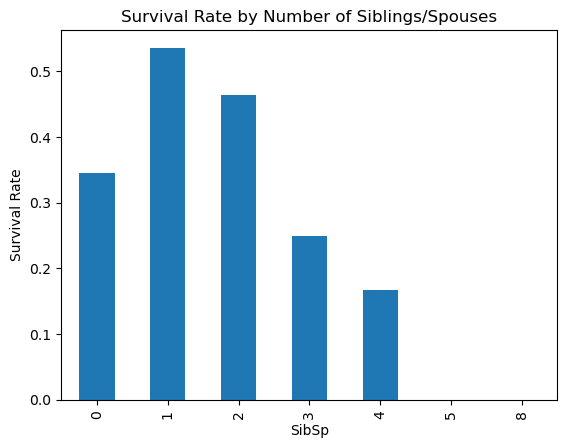

In [21]:
# Analyze survival rate based on number of siblings/spouses and visualize it 
survival_sibsp = df.groupby('SibSp')['Survived'].mean()
print(survival_sibsp)
survival_sibsp.plot(kind='bar')
plt.title("Survival Rate by Number of Siblings/Spouses")
plt.xlabel("SibSp")
plt.ylabel("Survival Rate")
plt.show()

In [22]:
# Calculate overall passenger survival percentage
survival_rate = df['Survived'].mean() * 100
print("Overall Survival Rate:")
print(round(survival_rate, 2), "%")

Overall Survival Rate:
38.38 %


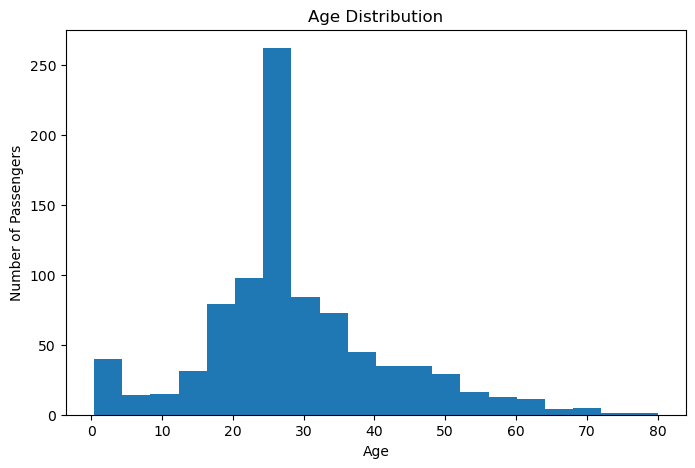

In [23]:
plt.figure(figsize=(8,5))
# Visualize age distribution of passengers
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

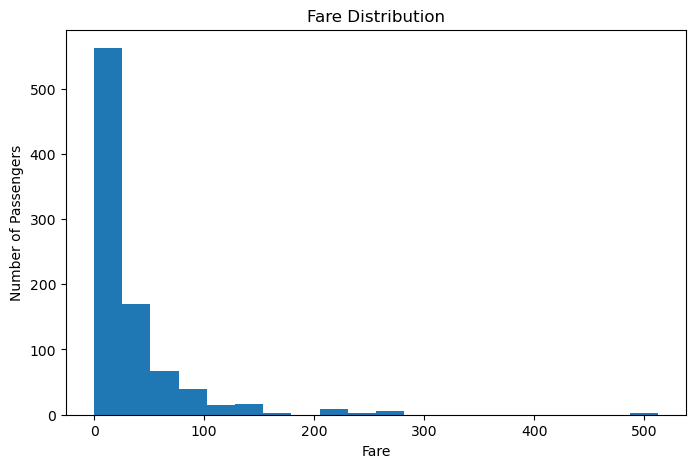

In [24]:
plt.figure(figsize=(8,5))
# Visualize ticket fare distribution
plt.hist(df['Fare'], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


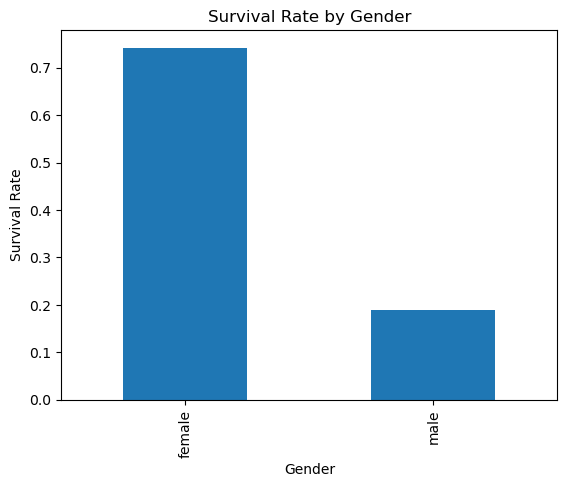

In [25]:
# Compare the survival rates of male and female passengers and visualize it
gender_survival = df.groupby('Sex')['Survived'].mean()
print(gender_survival)
gender_survival.plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


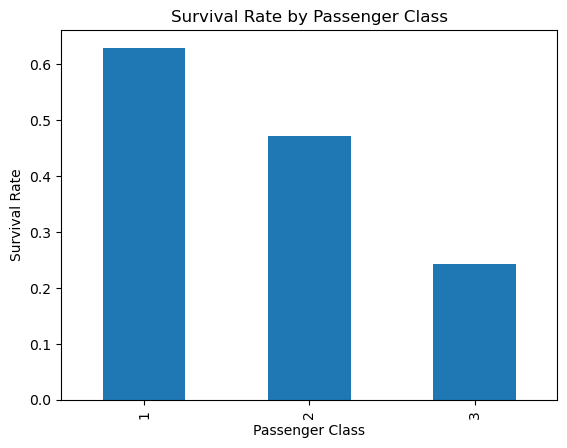

In [26]:
# Compare survival rates across passenger classes and visualize it
class_survival = df.groupby('Pclass')['Survived'].mean()
print(class_survival)
class_survival.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

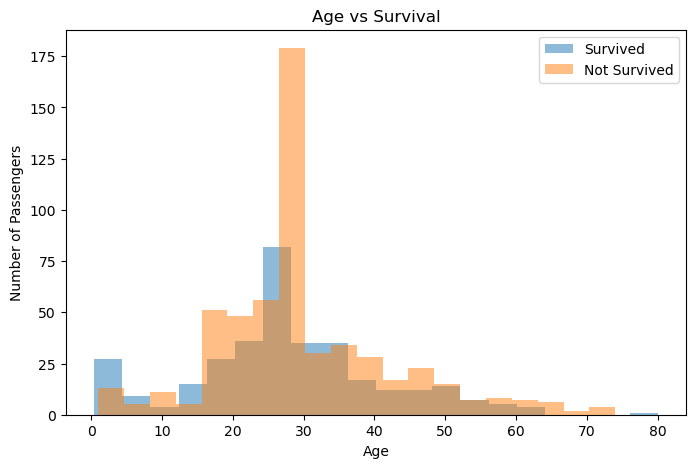

In [27]:
# Compare age distribution of survived and non-survived passengers and visualize it
survived = df[df['Survived'] == 1]
not_survived = df[df['Survived'] == 0]
plt.figure(figsize=(8,5))
plt.hist(survived['Age'], bins=20, alpha=0.5, label='Survived')
plt.hist(not_survived['Age'], bins=20, alpha=0.5, label='Not Survived')
plt.title("Age vs Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

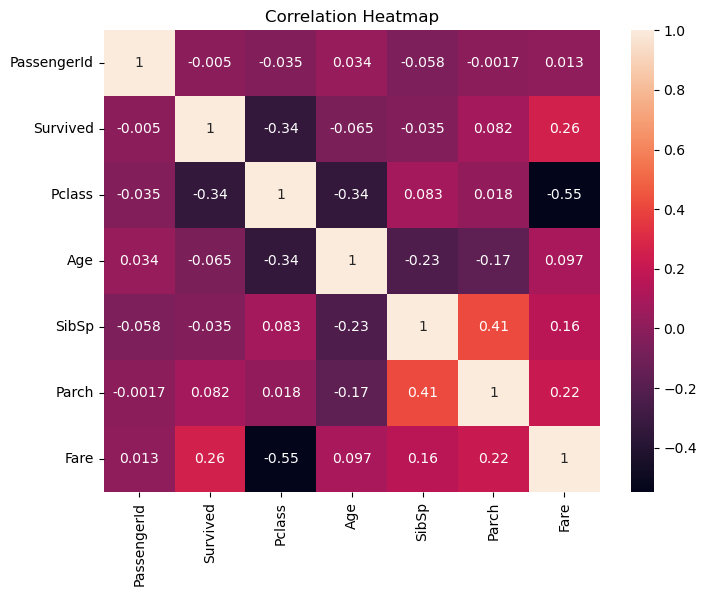

In [28]:
plt.figure(figsize=(8,6))
# Visualize correlation between numerical features
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
print("Survival Rate by Gender")
print(df.groupby('Sex')['Survived'].mean())
print("\nSurvival Rate by Passenger Class")
print(df.groupby('Pclass')['Survived'].mean())

Survival Rate by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
